<a href="https://colab.research.google.com/github/Johnogunlola/MRes-AI/blob/MRes/Accident_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
with open('NTSB Accident Report Dataset 2015-2025.csv', 'r', encoding='latin-1') as f:
    content = f.read()

In [ ]:
blocks = content.strip().split('?ProjectID=')
blocks = [b for b in blocks if b.strip()]

In [ ]:
rows = []

In [ ]:
# Define column names (based on your schema)
columns = [
    'ProjectID', 'EventDate', 'City', 'State', 'Country', 'N-Number', 'HasSafetyRec',
    'ReportType', 'HighestInjuryLevel', 'FatalInjuryCount', 'SeriousInjuryCount',
    'MinorInjuryCount', 'ProbableCause', 'Latitude', 'Longitude', 'Make', 'Model',
    'AirCraftCategory', 'AirportID', 'AirportName', 'AmateurBuilt', 'NumberOfEngines',
    'Scheduled', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition',
    'Operator', 'ReportStatus', 'RepGenFlag', 'DocketUrl', 'DocketPublishDate'
]

In [ ]:
for block in blocks:
    # Extract ProjectID
    parts = block.split(',', 1)
    project_id = parts[0].strip()
    data = parts[1] if len(parts) > 1 else ''

In [ ]:
 event_splits = re.split(r'(ACC|INC|OCC),(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z)', data)

In [ ]:
    if not re.match(r'\d{4}-\d{2}-\d{2}', event_splits[0]):
        event_splits = event_splits[1:]  # skip non-data part

In [ ]:
    for i in range(0, len(event_splits) - 1, 3):
        if i + 2 >= len(event_splits):
            break
        event_type = event_splits[i]
        timestamp = event_splits[i + 1]
        data_part = event_splits[i + 2]
        try:
            temp_df = pd.read_csv(StringIO(data_part), header=None, nrows=1, quotechar='"', escapechar='\\', engine='python')
            values = temp_df.values[0].tolist()
        except:
            values = data_part.split(',')[:len(columns)]
        while len(values) < len(columns):
            values.append('')
        values = values[:len(columns)]
        row = {col: val.strip() for col, val in zip(columns, values)}
        row['EventID'] = event_type
        row['EventDate'] = timestamp
        row['ProjectID'] = project_id
        rows.append(row)

In [ ]:
from io import StringIO
try:
    temp_df = pd.read_csv(StringIO(data_part), header=None, nrows=1, quotechar='"', escapechar='\\', engine='python')
    values = temp_df.values[0].tolist()
except:
    values = data_part.split(',')[:len(columns)]

In [ ]:
df = pd.DataFrame(rows)
display(df.head())

,ProjectID,EventDate,City,State,Country,N-Number,HasSafetyRec,ReportType,HighestInjuryLevel,FatalInjuryCount,...,PurposeOfFlight,FAR,AirCraftDamage,WeatherCondition,Operator,ReportStatus,RepGenFlag,DocketUrl,DocketPublishDate,EventID
0,90556,2015-01-01T05:00:00Z,nan,Portugal,CS-UJF,False,nan,Serious,0,2,...,nan,Destroyed,nan,nan,nan,False,nan,nan,,ACC


In [ ]:
while len(values) < len(columns):
    values.append('')
values = values[:len(columns)]

In [ ]:
row = {col: str(val).strip() for col, val in zip(columns, values)}
row['EventID'] = event_type
row['EventDate'] = timestamp
row['ProjectID'] = project_id
rows.append(row)

In [ ]:
df = pd.DataFrame(rows)

In [ ]:
df['EventDate'] = pd.to_datetime(df['EventDate'], errors='coerce')

In [ ]:
def split_concatenated(field, idx, values):
    parts = [p.strip() for p in str(values).split(',') if p.strip()]
    return parts[idx] if idx < len(parts) else np.nan

In [ ]:
expanded_rows = []

for _, row in df.iterrows():
    n_numbers = str(row['N-Number']).split(',')
    n_numbers = [n.strip() for n in n_numbers if n.strip() and n != '']

    if len(n_numbers) > 1:
        for i, n_num in enumerate(n_numbers):
            new_row = row.copy()
            fields_to_split = ['N-Number', 'Make', 'Model', 'AirCraftCategory', 'AmateurBuilt',
                               'NumberOfEngines', 'AirCraftDamage', 'WeatherCondition']
            for f in fields_to_split:
                if f in row and ',' in str(row[f]):
                    parts = [p.strip() for p in str(row[f]).split(',')]
                    new_row[f] = parts[i] if i < len(parts) else np.nan
            new_row['N-Number'] = n_num
            expanded_rows.append(new_row)
    else:
        expanded_rows.append(row)

df = pd.DataFrame(expanded_rows)

In [ ]:
df['AirCraftCategory'] = df['AirCraftCategory'].replace('', 'AIR').fillna('AIR')
df['PurposeOfFlight'] = df['PurposeOfFlight'].replace('', 'PUBF').fillna('PUBF')
df['FAR'] = df['FAR'].replace('', '91').fillna('91')
df['WeatherCondition'] = df['WeatherCondition'].replace('', 'VMC').fillna('VMC')
df['HighestInjuryLevel'] = df['HighestInjuryLevel'].replace('', 'None').fillna('None')

In [ ]:
df['FatalInjuryCount'] = pd.to_numeric(df['FatalInjuryCount'], errors='coerce').fillna(0).astype(int)
df['SeriousInjuryCount'] = pd.to_numeric(df['SeriousInjuryCount'], errors='coerce').fillna(0).astype(int)
df['MinorInjuryCount'] = pd.to_numeric(df['MinorInjuryCount'], errors='coerce').fillna(0).astype(int)

In [ ]:
df['TotalInjuries'] = df['FatalInjuryCount'] + df['SeriousInjuryCount'] + df['MinorInjuryCount']

In [ ]:
df['HighSeverity'] = (df['HighestInjuryLevel'] == 'Fatal') | (df['AirCraftDamage'] == 'Destroyed')

In [ ]:
df['HasSafetyRec'] = df['HasSafetyRec'].map({'TRUE': True, 'FALSE': False})
df['RepGenFlag'] = df['RepGenFlag'].map({'TRUE': True, 'FALSE': False})
df['AmateurBuilt'] = df['AmateurBuilt'].map({'TRUE': True, 'FALSE': False}, na_action='ignore')

In [ ]:
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

In [ ]:
df = df[~((df['Latitude'] == 0) & (df['Longitude'] == 0))]

In [ ]:
df['Year'] = df['EventDate'].dt.year
df['Month'] = df['EventDate'].dt.month
df['Hour'] = df['EventDate'].dt.hour
df['DayOfWeek'] = df['EventDate'].dt.dayofweek
df['IsNight'] = df['Hour'].between(18, 6, inclusive='left')  # Rough night flight

In [ ]:
df['PhaseOfFlight'] = 'Unknown'
df.loc[df['ProbableCause'].str.contains('takeoff', case=False, na=False), 'PhaseOfFlight'] = 'Takeoff'
df.loc[df['ProbableCause'].str.contains('landing|approach|go-around', case=False, na=False), 'PhaseOfFlight'] = 'Landing'
df.loc[df['ProbableCause'].str.contains('cruise|en route', case=False, na=False), 'PhaseOfFlight'] = 'Cruise'

In [ ]:
df['IsIMC'] = df['WeatherCondition'] == 'IMC'
df['IsPersonalFlight'] = df['PurposeOfFlight'] == 'PERS'
df['IsAmateurBuilt'] = df['AmateurBuilt'] == True

In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

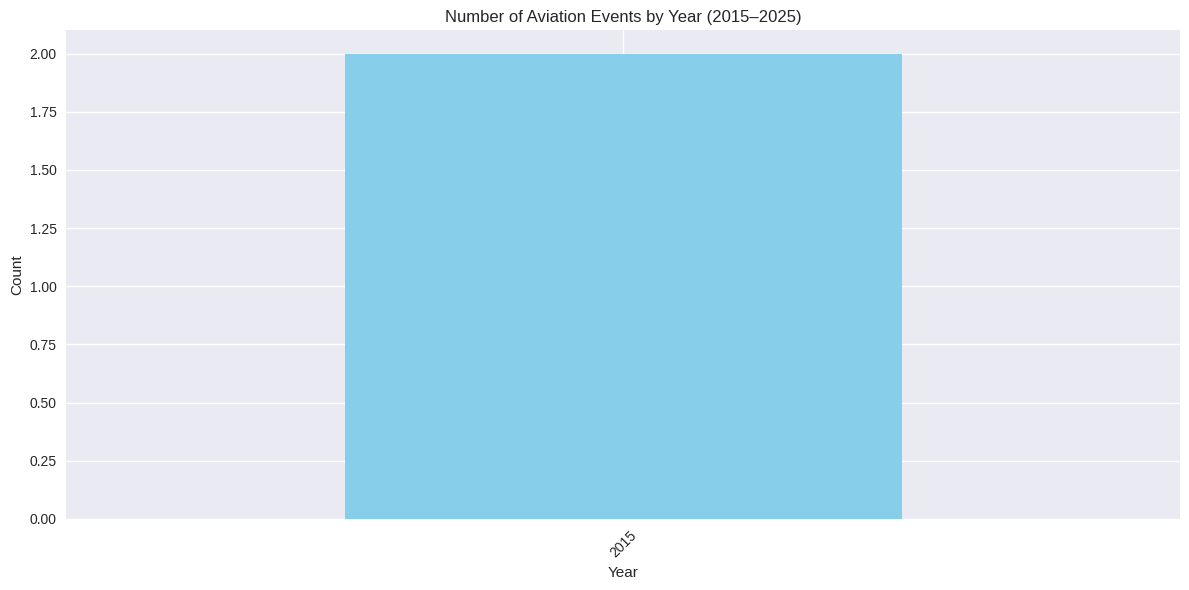

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby('Year').size().plot(kind='bar', color='skyblue')
plt.title('Number of Aviation Events by Year (2015–2025)')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

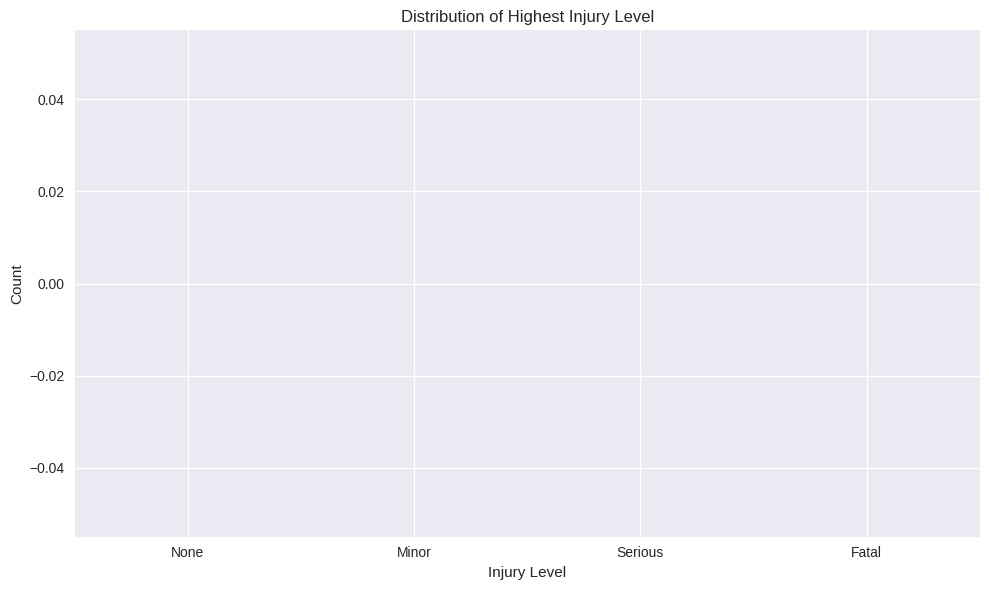

In [ ]:
plt.figure(figsize=(10, 6))
df['HighestInjuryLevel'].value_counts().reindex(['None', 'Minor', 'Serious', 'Fatal']).plot(kind='bar', color='coral')
plt.title('Distribution of Highest Injury Level')
plt.ylabel('Count')
plt.xlabel('Injury Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

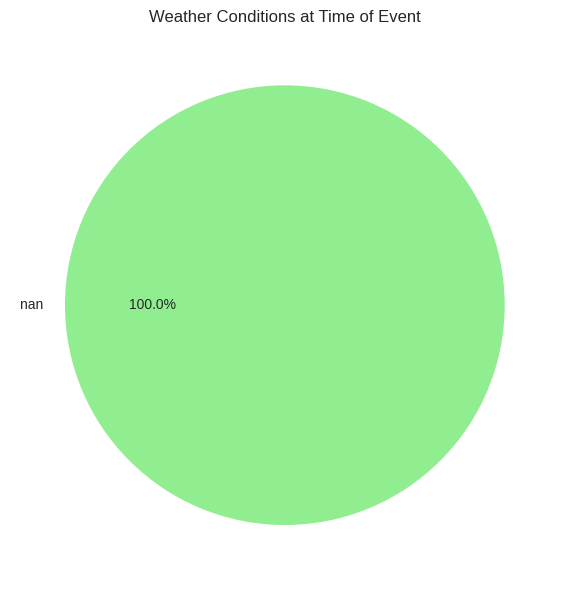

In [ ]:
plt.figure(figsize=(8, 6))
df['WeatherCondition'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'salmon', 'gray'])
plt.title('Weather Conditions at Time of Event')
plt.ylabel('')
plt.tight_layout()
plt.show()

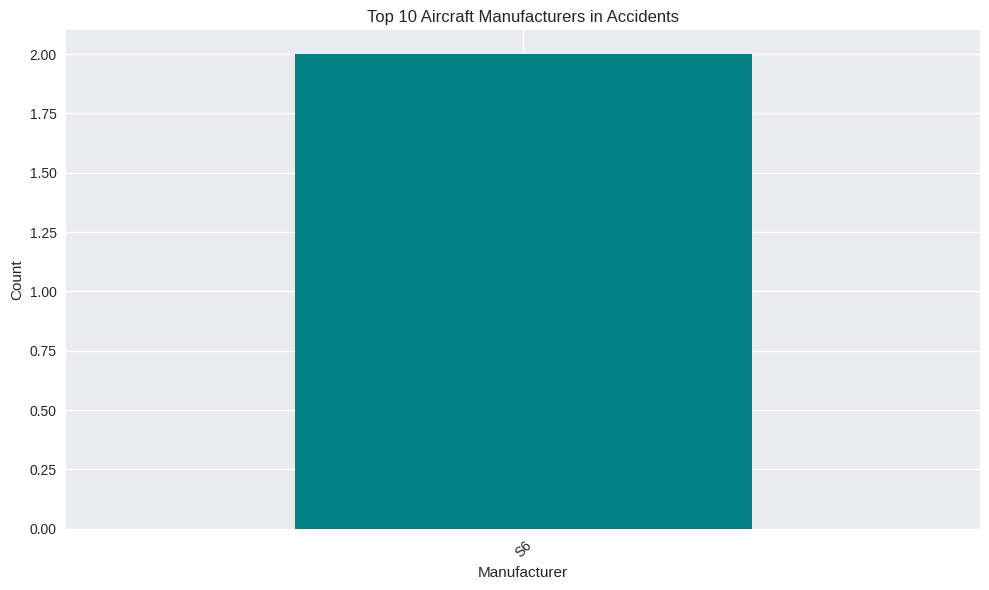

In [ ]:
top_makes = df['Make'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_makes.plot(kind='bar', color='teal')
plt.title('Top 10 Aircraft Manufacturers in Accidents')
plt.ylabel('Count')
plt.xlabel('Manufacturer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()